# v1 Primary Model — LightGBM

Ridge baseline established: val MAE = 12.49, R2 = 0.029.

Key differences from Ridge:
- No scaling required (tree splits are scale-invariant)
- No imputation required (LightGBM learns from NaN)
- Early stopping on val set prevents overfitting

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../")))

import mlflow
import mlflow.lightgbm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.models.train_v1 import train_lightgbm, load_v1_splits
from src.features.feature_columns import SENSING_FEATURES, TARGET

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mental_health_prediction")

RIDGE_BASELINE_VAL_MAE = 12.4904 # from notebook 01

print(f"Ridge baseline val MAE: {RIDGE_BASELINE_VAL_MAE}")
print(f"Features: {len(SENSING_FEATURES)}")

Ridge baseline val MAE: 12.4904
Features: 21


In [2]:
train, val, test = load_v1_splits()

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")
print(f"\nLabel mean — Train: {train[TARGET].mean():.1f} | "
      f"Val: {val[TARGET].mean():.1f} | Test: {test[TARGET].mean():.1f}")
print(f"Label std  — Train: {train[TARGET].std():.1f} | "
      f"Val: {val[TARGET].std():.1f} | Test: {test[TARGET].std():.1f}")

print(f"\nNaN counts in training features (after Android fix applied in train_lightgbm):")
nan_counts = train[SENSING_FEATURES].isna().sum()
print(nan_counts[nan_counts > 0])

Train: 6,940 | Val: 1,610 | Test: 1,381

Label mean — Train: 64.8 | Val: 64.1 | Test: 63.6
Label std  — Train: 15.8 | Val: 16.2 | Test: 16.4

NaN counts in training features (after Android fix applied in train_lightgbm):
other_playing_duration_ep_0_mean    409
other_playing_duration_ep_0_std     410
dtype: int64


In [3]:
# Default hyperparameters first
model_default, metrics_default = train_lightgbm(
    n_estimators=1000,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    min_child_samples=20,
    run_name="v1_lgbm_default"
)

print(f"\nComparison:")
print(f"  Ridge    val MAE: {RIDGE_BASELINE_VAL_MAE}")
print(f"  LightGBM val MAE: {metrics_default['val_mae']}")
improvement = RIDGE_BASELINE_VAL_MAE - metrics_default['val_mae']
print(f"  Improvement     : {improvement:.4f} ({improvement/RIDGE_BASELINE_VAL_MAE*100:.1f}%)")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000864 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

2026/04/12 20:14:17 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_default at: http://localhost:5000/#/experiments/2/runs/b77c998f5c1c4dd4b5840682df9751bb
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=58)
  train MAE: 10.7671  R2: 0.2613
  val   MAE: 12.3772   R2: 0.0399
  test  MAE: 12.9955   R2: -0.0246

Comparison:
  Ridge    val MAE: 12.4904
  LightGBM val MAE: 12.3772
  Improvement     : 0.1132 (0.9%)


In [4]:
configs = [
    {"learning_rate": 0.01,  "max_depth": 4, "num_leaves": 15, "min_child_samples": 20},
    {"learning_rate": 0.01,  "max_depth": 6, "num_leaves": 31, "min_child_samples": 20},
    {"learning_rate": 0.05,  "max_depth": 4, "num_leaves": 15, "min_child_samples": 10},
    {"learning_rate": 0.05,  "max_depth": 6, "num_leaves": 31, "min_child_samples": 10},
    {"learning_rate": 0.05,  "max_depth": 8, "num_leaves": 63, "min_child_samples": 20},
    {"learning_rate": 0.1,   "max_depth": 4, "num_leaves": 15, "min_child_samples": 20},
]

tuning_results = []

for i, cfg in enumerate(configs):
    _, metrics = train_lightgbm(
        **cfg,
        n_estimators=1000,
        run_name=f"v1_lgbm_tune_{i}"
    )
    tuning_results.append({**cfg, **metrics})
    print(f"Config {i}: lr={cfg['learning_rate']}, depth={cfg['max_depth']}, "
          f"leaves={cfg['num_leaves']} → val_mae={metrics['val_mae']:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values("val_mae")
print(f"\nTop 3 configurations by val_mae:")
print(tuning_df[["learning_rate", "max_depth", "num_leaves",
                  "min_child_samples", "val_mae", "test_mae"]].head(3).to_string(index=False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

2026/04/12 20:15:39 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_0 at: http://localhost:5000/#/experiments/2/runs/98279fdb1fc04c5aa20f18e787911fdf
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=253)
  train MAE: 11.4474  R2: 0.1635
  val   MAE: 12.4427   R2: 0.0343
  test  MAE: 12.9801   R2: -0.0173
Config 0: lr=0.01, depth=4, leaves=15 → val_mae=12.4427
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

2026/04/12 20:15:49 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_1 at: http://localhost:5000/#/experiments/2/runs/964c46526d924d078817bcc6b7db8179
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=219)
  train MAE: 11.0134  R2: 0.2274
  val   MAE: 12.3815   R2: 0.041
  test  MAE: 12.9685   R2: -0.0175
Config 1: lr=0.01, depth=6, leaves=31 → val_mae=12.3815
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

...

🏃 View run v1_lgbm_tune_3 at: http://localhost:5000/#/experiments/2/runs/241b28c5db474503b64ac2b31c59eb03
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=46)
  train MAE: 10.9025  R2: 0.2446
  val   MAE: 12.3793   R2: 0.0426
  test  MAE: 12.976   R2: -0.018
Config 3: lr=0.05, depth=6, leaves=31 → val_mae=12.3793
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

2026/04/12 20:16:24 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_4 at: http://localhost:5000/#/experiments/2/runs/e0651f098b134881883c0ce46ac09feb
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=47)
  train MAE: 10.1448  R2: 0.3418
  val   MAE: 12.3486   R2: 0.0379
  test  MAE: 13.048   R2: -0.0332
Config 4: lr=0.05, depth=8, leaves=63 → val_mae=12.3486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

2026/04/12 20:16:37 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_5 at: http://localhost:5000/#/experiments/2/runs/22758c799ee547458f39c658210b9f2b
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=109)
  train MAE: 10.4905  R2: 0.2918
  val   MAE: 12.3271   R2: 0.0437
  test  MAE: 13.1128   R2: -0.0377
Config 5: lr=0.1, depth=4, leaves=15 → val_mae=12.3271

Top 3 configurations by val_mae:
 learning_rate  max_depth  num_leaves  min_child_samples  val_mae  test_mae
          0.10          4          15                 20  12.3271   13.1128
          0.05          8          63                 20  12.3486   13.0480
          0.05          4          15                 10  12.3754   12.9850


Best config: lr=0.1, depth=4.0, leaves=15.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5102
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 21
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

2026/04/12 20:17:41 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_best at: http://localhost:5000/#/experiments/2/runs/a800e5394a7444479fc16ae6539793d2
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=109)
  train MAE: 10.4905  R2: 0.2918
  val   MAE: 12.3271   R2: 0.0437
  test  MAE: 13.1128   R2: -0.0377


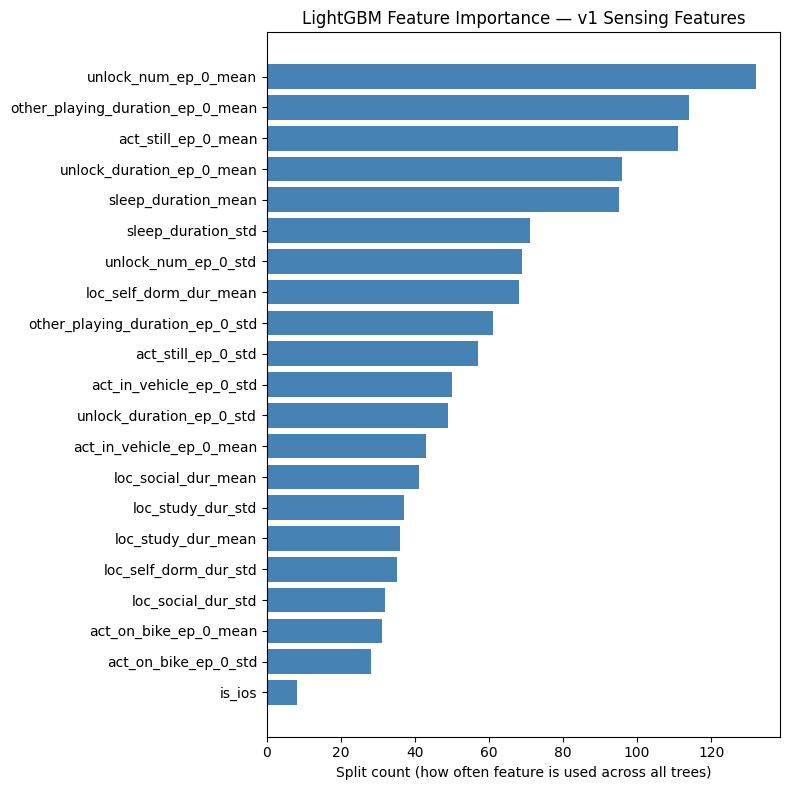


Top 5 most important features:
                         feature  importance
            unlock_num_ep_0_mean         132
other_playing_duration_ep_0_mean         114
             act_still_ep_0_mean         111
       unlock_duration_ep_0_mean          96
             sleep_duration_mean          95


In [5]:
best_config = tuning_df.iloc[0]
print(f"Best config: lr={best_config['learning_rate']}, "
      f"depth={best_config['max_depth']}, leaves={best_config['num_leaves']}")

# Retrain best config explicitly to get the model object
best_model, best_metrics = train_lightgbm(
    learning_rate=float(best_config["learning_rate"]),
    max_depth=int(best_config["max_depth"]),
    num_leaves=int(best_config["num_leaves"]),
    min_child_samples=int(best_config["min_child_samples"]),
    n_estimators=1000,
    run_name="v1_lgbm_best"
)

# Plot feature importance
fi = pd.DataFrame({
    "feature":    SENSING_FEATURES,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(fi["feature"], fi["importance"], color="steelblue")
ax.set_xlabel("Split count (how often feature is used across all trees)")
ax.set_title("LightGBM Feature Importance — v1 Sensing Features")
plt.tight_layout()
plt.savefig("../../outputs/figures/v1_lgbm_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(fi.sort_values("importance", ascending=False).head(5).to_string(index=False))

In [6]:
print("=" * 55)
print("MODEL COMPARISON — v1 PRE-COVID DATA")
print("=" * 55)
print(f"\n{'Model':<25} {'val MAE':>10} {'test MAE':>10} {'val R2':>8}")
print("-" * 55)
print(f"{'Ridge (alpha=100)':25} {RIDGE_BASELINE_VAL_MAE:>10.4f} "
      f"{12.9785:>10.4f} {0.029:>8.4f}")
print(f"{'LightGBM (best)':25} {best_metrics['val_mae']:>10.4f} "
      f"{best_metrics['test_mae']:>10.4f} {best_metrics['val_r2']:>8.4f}")
print()

improvement_val  = RIDGE_BASELINE_VAL_MAE - best_metrics["val_mae"]
improvement_pct  = improvement_val / RIDGE_BASELINE_VAL_MAE * 100
print(f"Val MAE improvement over Ridge: {improvement_val:.4f} ({improvement_pct:.1f}%)")

if improvement_val > 0:
    print("\nLightGBM outperforms Ridge — proceed to registration.")
else:
    print("\nLightGBM does not outperform Ridge — investigate before registering.")
    print("Check: are features properly computed? Is NaN handling correct?")
    print("Consider: the sensing features may have limited predictive power.")
    print("This is a valid scientific finding, not a pipeline failure.")

MODEL COMPARISON — v1 PRE-COVID DATA

Model                        val MAE   test MAE   val R2
-------------------------------------------------------
Ridge (alpha=100)            12.4904    12.9785   0.0290
LightGBM (best)              12.3271    13.1128   0.0437

Val MAE improvement over Ridge: 0.1633 (1.3%)

LightGBM outperforms Ridge — proceed to registration.
